In [ ]:
#--------------------------Loan Approval Prediction System-----------------------
#-----------------A Machine Learning Approach Using Random Forest Classifier------

In [1]:
# NumPy is used for numerical calculations and generating random data
import numpy as np

# Pandas is used for creating and handling the dataset
import pandas as pd

# Matplotlib is used for creating graphs and visualizations
import matplotlib.pyplot as plt

# Seaborn is used for advanced statistical visualizations
import seaborn as sns

# train_test_split divides the dataset into training and testing data
from sklearn.model_selection import train_test_split

# RandomForestClassifier is the machine learning classification algorithm
from sklearn.ensemble import RandomForestClassifier

# These metrics are used to evaluate the performance of the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Set random seed so that the same random values are generated every time
np.random.seed(42)

# Number of loan applicants in our synthetic dataset
n = 500

# Create a DataFrame containing information about 500 applicants
df = pd.DataFrame({

    # Generate applicant ages between 21 and 60
    "Age": np.random.randint(21, 61, n),

    # Generate annual income values between 20,000 and 150,000
    "Income": np.random.randint(20000, 150001, n),

    # Generate credit scores between 500 and 850
    "Credit_Score": np.random.randint(500, 851, n),

    # Generate loan amounts between 50,000 and 1,000,000
    "Loan_Amount": np.random.randint(50000, 1000001, n),

    # Generate employment experience between 0 and 20 years
    "Employment_Years": np.random.randint(0, 21, n),

    # Generate number of existing loans between 0 and 3
    "Existing_Loans": np.random.randint(0, 4, n),

    # Generate number of dependents between 0 and 4
    "Dependents": np.random.randint(0, 5, n)
})

# Display first 5 rows of the dataset
df.head()

,Age,Income,Credit_Score,Loan_Amount,Employment_Years,Existing_Loans,Dependents
0,59,71934,788,978626,10,2,4
1,49,84895,649,392703,2,1,3
2,35,52307,776,254615,5,3,3
3,28,74098,697,526657,8,0,1
4,41,80921,569,616074,5,3,2


In [3]:
# Calculate an approval score for every applicant
# Higher income and credit score increase the score
# Higher loan amount, existing loans and dependents decrease the score

score = (
    # Income contributes positively to the approval score
    df["Income"] * 0.0002 +

    # Credit score has a positive effect on approval
    df["Credit_Score"] * 0.25 +

    # More employment experience increases the score
    df["Employment_Years"] * 2 -

    # A larger loan amount decreases the score
    df["Loan_Amount"] * 0.00008 -

    # Existing loans reduce the score
    df["Existing_Loans"] * 8 -

    # More dependents slightly reduce the score
    df["Dependents"] * 2
)

# If the score is 145 or above, classify the applicant as Approved
# Otherwise, classify the applicant as Rejected
df["Loan_Status"] = np.where(
    score >= 145,
    "Approved",
    "Rejected"
)

# Display the first 5 rows including the new Loan_Status column
df.head()

,Age,Income,Credit_Score,Loan_Amount,Employment_Years,Existing_Loans,Dependents,Loan_Status
0,59,71934,788,978626,10,2,4,Rejected
1,49,84895,649,392703,2,1,3,Rejected
2,35,52307,776,254615,5,3,3,Approved
3,28,74098,697,526657,8,0,1,Approved
4,41,80921,569,616074,5,3,2,Rejected


In [4]:
# Display the number of rows and columns in the dataset
print("Dataset Shape:", df.shape)

# Display the number of Approved and Rejected applicants
print("\nLoan Status Distribution:")
print(df["Loan_Status"].value_counts())

# Check whether the dataset contains any missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (500, 8)

Loan Status Distribution:
Loan_Status
Approved    258
Rejected    242
Name: count, dtype: int64

Missing Values:
Age                 0
Income              0
Credit_Score        0
Loan_Amount         0
Employment_Years    0
Existing_Loans      0
Dependents          0
Loan_Status         0
dtype: int64


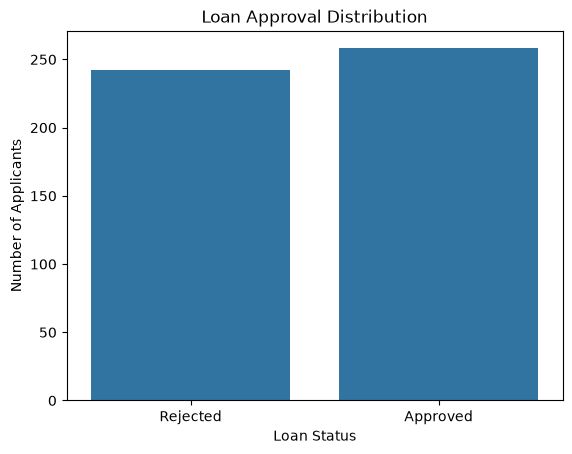

In [5]:
# Create a count plot showing Approved and Rejected applicants
sns.countplot(x="Loan_Status", data=df)

# Add a title to the graph
plt.title("Loan Approval Distribution")

# Label the x-axis
plt.xlabel("Loan Status")

# Label the y-axis
plt.ylabel("Number of Applicants")

# Display the graph
plt.show()

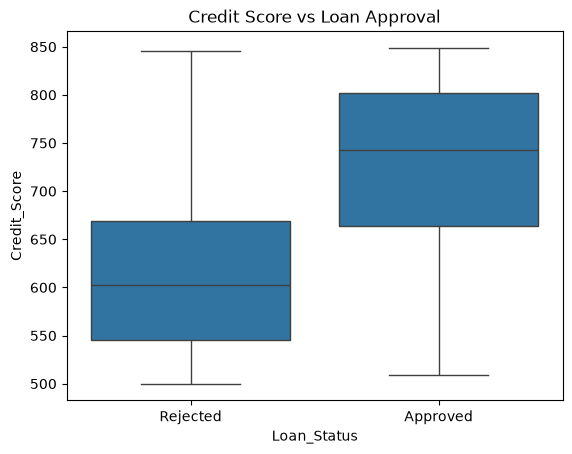

In [6]:
# Create a box plot to compare credit scores
# between Approved and Rejected applicants
sns.boxplot(
    x="Loan_Status",
    y="Credit_Score",
    data=df
)

# Add title to the graph
plt.title("Credit Score vs Loan Approval")

# Display the graph
plt.show()

In [7]:
# X contains all independent/input features
# Loan_Status is removed because it is our target
X = df.drop("Loan_Status", axis=1)

# Convert the target labels into numerical values
# Rejected = 0
# Approved = 1
y = df["Loan_Status"].map({
    "Rejected": 0,
    "Approved": 1
})

# Display the first few input records
print("Input Features:")
print(X.head())

# Display the first few target values
print("\nTarget Values:")
print(y.head())

Input Features:
   Age  Income  Credit_Score  Loan_Amount  Employment_Years  Existing_Loans  \
0   59   71934           788       978626                10               2   
1   49   84895           649       392703                 2               1   
2   35   52307           776       254615                 5               3   
3   28   74098           697       526657                 8               0   
4   41   80921           569       616074                 5               3   

   Dependents  
0           4  
1           3  
2           3  
3           1  
4           2  

Target Values:
0    0
1    0
2    1
3    1
4    0
Name: Loan_Status, dtype: int64


In [8]:
# Split the dataset into training and testing sets
# 80% data will be used for training
# 20% data will be used for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Input features
    y,                  # Target variable
    test_size=0.2,      # 20% data for testing
    random_state=42,    # Makes the split reproducible
    stratify=y          # Maintains the class distribution
)

# Display the number of training samples
print("Training samples:", len(X_train))

# Display the number of testing samples
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


In [9]:
# Create a Random Forest classification model
# n_estimators=100 means the model will use 100 decision trees

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the Random Forest model using the training data
model.fit(X_train, y_train)

# Display confirmation after training
print("Model training completed!")

Model training completed!


In [10]:
# Use the trained model to predict loan status
# for the test dataset
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
# Accuracy = Correct Predictions / Total Predictions
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy in percentage
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 91.0 %


In [11]:
# Generate a detailed classification report
# It contains precision, recall, F1-score and support

print(classification_report(
    y_test,                         # Actual values
    y_pred,                         # Predicted values
    target_names=["Rejected", "Approved"]  # Class names
))

              precision    recall  f1-score   support

    Rejected       0.91      0.90      0.91        48
    Approved       0.91      0.92      0.91        52

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



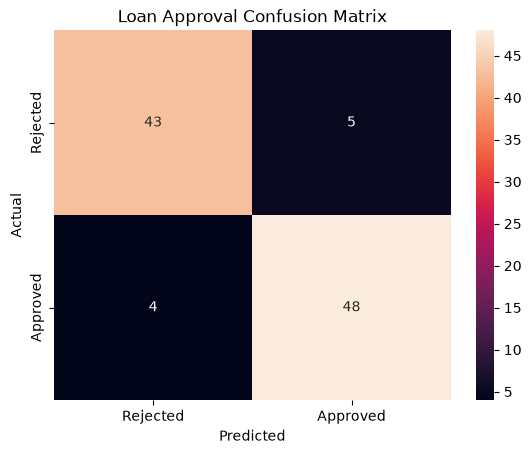

In [12]:
# Create a confusion matrix using actual and predicted values
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix as a heatmap
sns.heatmap(
    cm,

    # Display numerical values inside each cell
    annot=True,

    # Display values as integers
    fmt="d",

    # Labels for predicted classes
    xticklabels=["Rejected", "Approved"],

    # Labels for actual classes
    yticklabels=["Rejected", "Approved"]
)

# Label the x-axis
plt.xlabel("Predicted")

# Label the y-axis
plt.ylabel("Actual")

# Add title
plt.title("Loan Approval Confusion Matrix")

# Display the graph
plt.show()

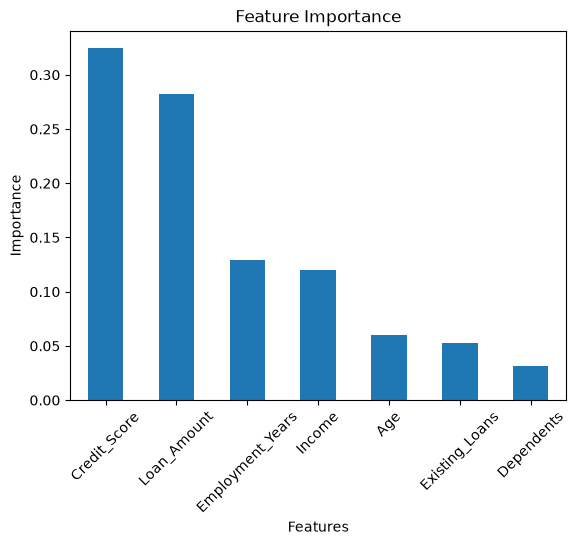

In [13]:
# Get the importance of every feature from the Random Forest model
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

# Sort features from most important to least important
importance = importance.sort_values(ascending=False)

# Create a bar graph of feature importance
importance.plot(kind="bar")

# Add graph title
plt.title("Feature Importance")

# Label x-axis
plt.xlabel("Features")

# Label y-axis
plt.ylabel("Importance")

# Rotate feature names for better readability
plt.xticks(rotation=45)

# Display the graph
plt.show()


In [14]:
# Create information for a new loan applicant
new_applicant = pd.DataFrame({

    # Age of the applicant
    "Age": [30],

    # Annual income of the applicant
    "Income": [85000],

    # Credit score of the applicant
    "Credit_Score": [760],

    # Requested loan amount
    "Loan_Amount": [300000],

    # Number of years employed
    "Employment_Years": [6],

    # Number of existing loans
    "Existing_Loans": [0],

    # Number of dependents
    "Dependents": [2]
})

# Predict whether the new applicant will be approved or rejected
prediction = model.predict(new_applicant)

# Get probability for both classes
# [0] = Rejected probability
# [1] = Approved probability
probability = model.predict_proba(new_applicant)

# Check the predicted class
if prediction[0] == 1:

    # If prediction is 1, the loan is approved
    print("Loan Prediction: APPROVED")

else:

    # If prediction is 0, the loan is rejected
    print("Loan Prediction: REJECTED")

# Display the probability of loan approval
print(
    "Approval Probability:",
    round(probability[0][1] * 100, 2),
    "%"
)

Loan Prediction: APPROVED
Approval Probability: 96.0 %
